# Oasis Infobyte — Data Science Internship

## Task 1: Iris Flower Classification

**Intern Name:** Rramandeip Singh  
**Internship Program:** Oasis Infobyte SIP  
**Track:** Data Science  
**Task:** Task 1 — Iris Flower Classification

### Objective

The objective of this task is to build a machine learning classification model that can identify the species of an iris flower based on its physical measurements.

The three iris species are:

- Setosa
- Versicolor
- Virginica

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Project Workflow

1. Load the Iris dataset
2. Perform data exploration and preprocessing
3. Conduct Exploratory Data Analysis (EDA)
4. Visualize the dataset
5. Select and analyze important features
6. Split the data into training and testing sets
7. Train multiple machine learning classification models
8. Evaluate model performance
9. Compare the models
10. Identify the best-performing model

## Libraries Used

The following Python libraries are used in this project:

- **Pandas** — For data manipulation and analysis
- **NumPy** — For numerical operations
- **Matplotlib** — For creating data visualizations
- **Seaborn** — For statistical data visualization
- **Scikit-learn** — For dataset loading, preprocessing, machine learning models, and model evaluation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,
                            confusion_matrix,
                            classification_report)

## Load the Iris Dataset

The Iris dataset is a built-in dataset available through Scikit-learn. It contains measurements of iris flowers from three species: Setosa, Versicolor, and Virginica.

The dataset includes four features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In [6]:
# Load the Iris dataset
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [9]:
# Display dataset information
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nDataset shape:")
print(iris.data.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


## Convert the Dataset into a DataFrame

The Iris dataset is converted into a Pandas DataFrame to make the data easier to inspect, analyze, and visualize.

In [16]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Convert Species Labels into Names

The target values in the Iris dataset are represented as numerical labels. These values are converted into the corresponding species names to make the dataset easier to understand and analyze.

In [17]:
# Convert numerical target values into species names
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure and characteristics of the Iris dataset. This includes checking the dataset size, data types, missing values, and basic statistical information.

In [18]:
# Check the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


###  Data Types

The data types of each column are checked to ensure that the features are stored in an appropriate format for analysis and machine learning.

In [19]:
# Display the data type of each column
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

### Missing Values

The dataset is checked for missing values to determine whether any data cleaning is required before performing further analysis.

In [20]:
# Check for missing values in each column
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### Descriptive Statistics

Descriptive statistics are used to summarize the numerical features of the Iris dataset, including their mean, standard deviation, minimum, maximum, and quartile values.

In [21]:
# Generate descriptive statistics for the numerical features
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


###  Species Distribution

The distribution of the three Iris species is visualized to examine the number of observations available for each class.

In [22]:
# Count the number of observations for each species
species_counts = df["species"].value_counts()

print(species_counts)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


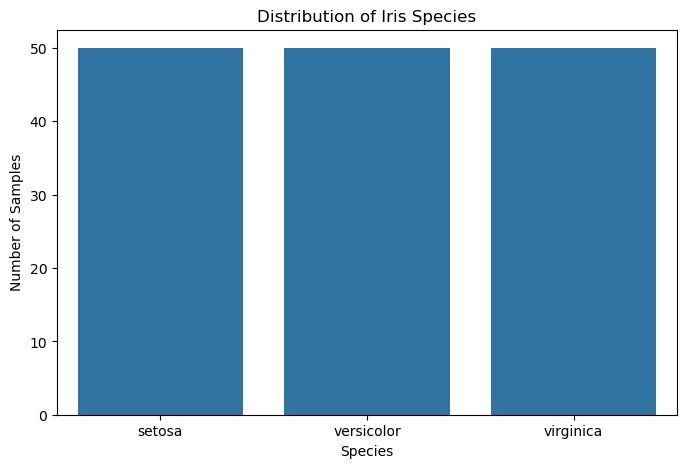

In [24]:
# Visualize the distribution of Iris species
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

###  Pairplot of Iris Features

A pairplot is used to visualize the relationships between the numerical features of the Iris dataset. The different colors represent the three Iris species, helping us identify patterns and separation between the classes.

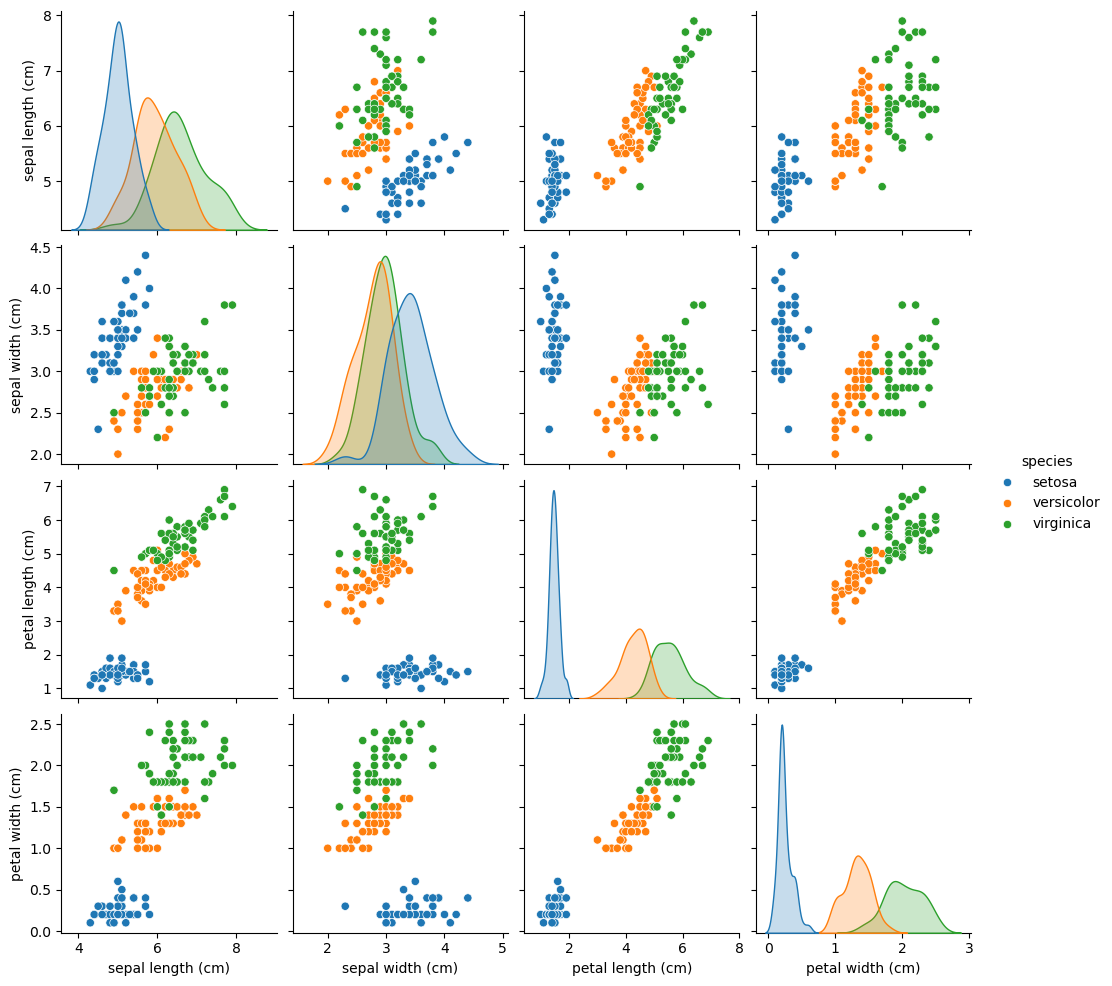

In [25]:
# Create a pairplot to compare the Iris features
sns.pairplot(df, hue="species")

plt.show()

### Pairplot Observation

The pairplot shows that the Iris species have different patterns across their measurements. Petal length and petal width provide clearer separation between the species, while some overlap can be observed in the sepal measurements.

###  Box Plot Analysis

Box plots are used to compare the distribution of each numerical feature across the three Iris species. They help identify differences in feature values, variation, and possible outliers.

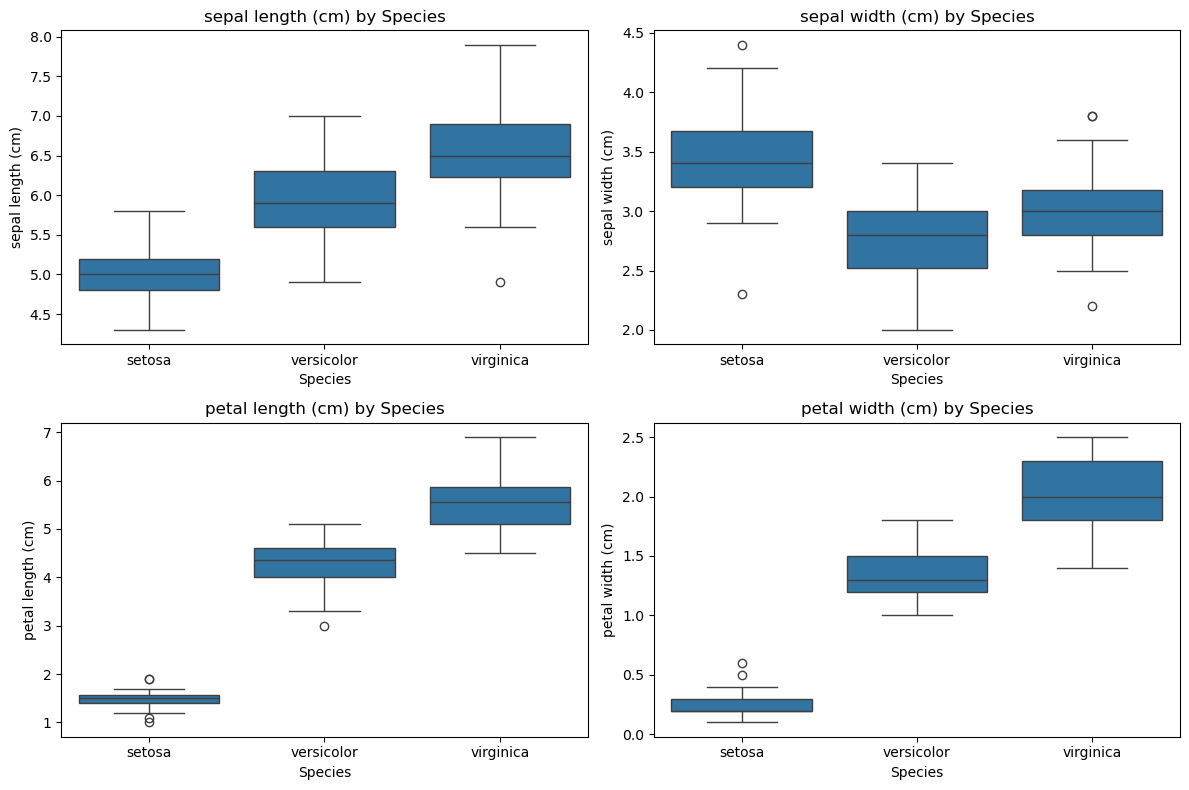

In [26]:
# Create box plots for each numerical feature
features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(
        data=df,
        x="species",
        y=feature)
    
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### Box Plot Observation

The box plots show clear differences in the feature distributions across the three Iris species. Petal length and petal width show the strongest separation between the species, with very little overlap. Sepal length also shows noticeable differences, while sepal width has more overlap between the species. Overall, petal length and petal width appear to be the most useful features for distinguishing the Iris species.

## Feature Selection

Feature selection is performed to identify which measurements provide the most useful information for distinguishing between the three Iris species. The relationships between the numerical features are examined using a correlation matrix.

In [27]:
# Calculate the correlation between the numerical features
correlation = df[iris.feature_names].corr()

# Display the correlation matrix
correlation

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


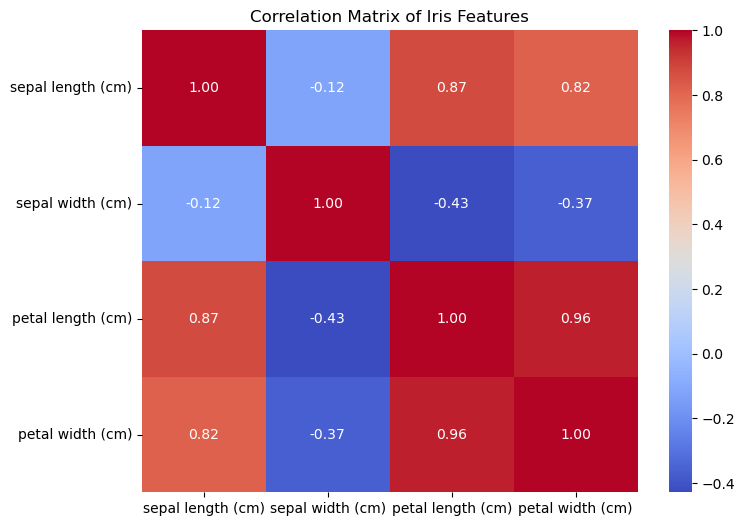

In [29]:
# Visualize the feature correlations
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Iris Features")
plt.show()

### Feature Selection Observation

The correlation matrix shows the relationships between the four numerical features. Petal length and petal width have a strong positive correlation, indicating that they tend to increase together. Based on the pairplot and box plots, petal length and petal width also provide clearer separation between the three Iris species. Therefore, these features appear to be particularly useful for classification.

##  Preparing Data for Machine Learning

The dataset is divided into training and testing sets so that the machine learning models can be trained on one portion of the data and evaluated on unseen data. An 80% training and 20% testing split is used.

In [30]:
# Define the input features and target variable
X = df[iris.feature_names]
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [31]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


### Train-Test Split Observation

The dataset contains 150 observations. Using an 80/20 split, 120 observations are used for training the machine learning models and 30 observations are reserved for testing. The testing data is kept separate so that model performance can be evaluated on previously unseen observations.

##  Feature Scaling

Feature scaling is applied to standardize the numerical features so that they have a similar scale. StandardScaler is used to transform the training and testing data before training the machine learning models.

In [32]:
# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Feature Scaling Observation

The numerical features have been standardized using StandardScaler. The scaler is fitted only on the training data and then applied to both the training and testing data to avoid data leakage.

##  Model Training

###  Logistic Regression

Logistic Regression is used as the first classification model to predict the species of an Iris flower based on its four physical measurements.

In [33]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model using the scaled training data
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


##  Logistic Regression Model Evaluation

The performance of the Logistic Regression model is evaluated using accuracy, confusion matrix, and classification report. These metrics help determine how well the model predicts the Iris flower species.

In [34]:
# Calculate the accuracy of the Logistic Regression model
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


###  Classification Report

The classification report provides precision, recall, and F1-score for each Iris species. These metrics provide a more detailed view of the model's classification performance.

In [35]:
# Display the classification report
print(classification_report( y_test, logistic_predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Confusion Matrix

A confusion matrix is used to compare the actual Iris species with the species predicted by the Logistic Regression model.

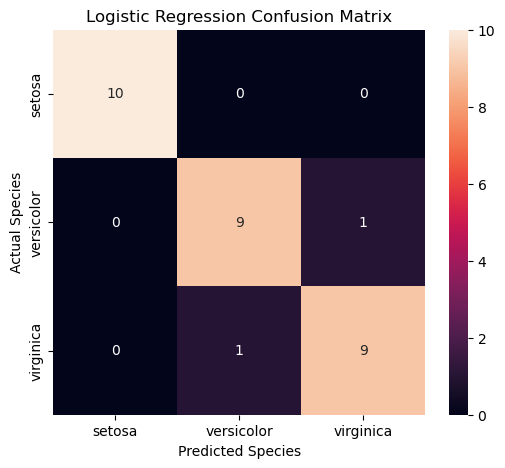

In [39]:
# Calculate the confusion matrix
logistic_cm = confusion_matrix(y_test, logistic_predictions)

# Display the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(logistic_cm, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

### Logistic Regression Evaluation Observation

The Logistic Regression model achieved an accuracy of approximately 93.33% on the test dataset. The classification report shows strong precision, recall, and F1-scores across the three Iris species. The confusion matrix shows that 28 out of 30 test samples were classified correctly, with two samples being misclassified.

##  K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is used as the second classification model. The model classifies each flower based on the species of its nearest observations in the feature space.

In [40]:
# Create the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
knn_predictions = knn_model.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


##  KNN Model Evaluation

The performance of the K-Nearest Neighbors (KNN) model is evaluated using accuracy, classification report, and confusion matrix.

In [41]:
# Calculate the accuracy of the KNN model
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


###  Classification Report

The classification report provides precision, recall, and F1-score for each Iris species predicted by the KNN model.

In [42]:
# Display the classification report for KNN
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



###  Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified observations for each Iris species.

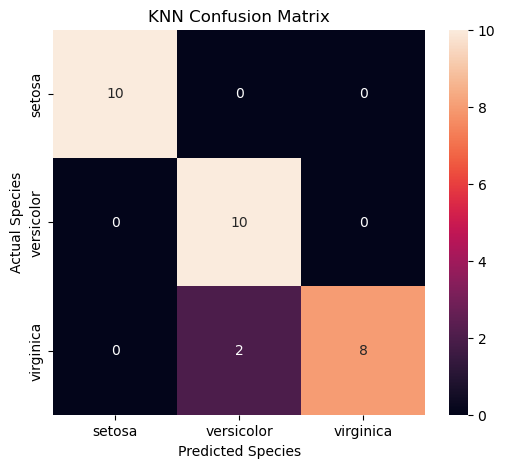

In [44]:
# Calculate the KNN confusion matrix
knn_cm = confusion_matrix(y_test, knn_predictions)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(knn_cm, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

### KNN Evaluation Observation

The KNN model performed well on the test dataset, achieving an accuracy of approximately 93.33%. The classification report shows strong precision, recall, and F1-scores across the three Iris species. The confusion matrix indicates that most observations were correctly classified.

### Best Model Comparison

Based on the accuracy comparison, Logistic Regression and K-Nearest Neighbors achieved the same accuracy of 93.33% on the test dataset. Therefore, both models demonstrated equal performance based on accuracy, and neither model can be considered superior using accuracy alone.

In [46]:
# Create a table comparing the model accuracy
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors"], "Accuracy": [logistic_accuracy, knn_accuracy]})

model_results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333


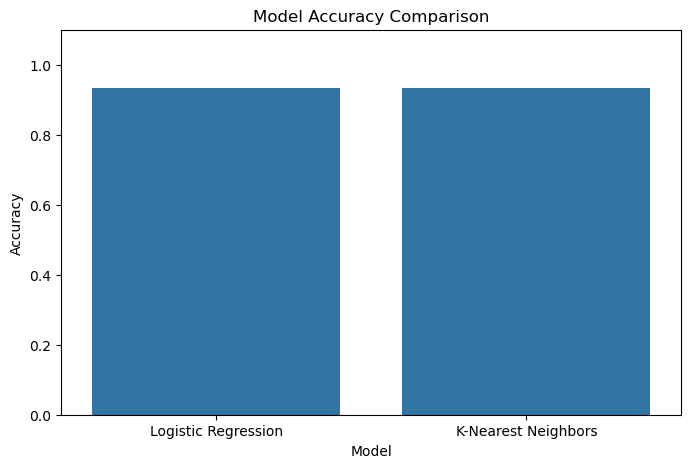

In [47]:
# Visualize the accuracy of both models
plt.figure(figsize=(8, 5))

sns.barplot(data=model_results, x="Model", y="Accuracy")

plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

### Best Model Observation

Based on the accuracy comparison, Logistic Regression is the best-performing model for this dataset. It achieved the highest accuracy on the test data compared with the K-Nearest Neighbors model. Therefore, Logistic Regression is selected as the final model for Iris flower classification.

##  Final Prediction

The trained Logistic Regression model is used to predict the species of a new Iris flower based on its sepal and petal measurements.

In [51]:
# Example measurements for a new Iris flower
new_flower = pd.DataFrame(
    [[5.8, 3.0, 4.5, 1.5]],
    columns=iris.feature_names)

# Scale the new data using the fitted scaler
new_flower_scaled = scaler.transform(new_flower)

# Predict the species
prediction = logistic_model.predict(new_flower_scaled)

print("Predicted Iris Species:", prediction[0])

Predicted Iris Species: versicolor


### Prediction Observation

The trained Logistic Regression model predicted that the new Iris flower belongs to the **versicolor** species based on the provided sepal and petal measurements.

## Conclusion

In this project, an Iris flower classification system was developed using machine learning. Exploratory Data Analysis showed that petal length and petal width provide strong separation between the three Iris species.

Two classification models, Logistic Regression and K-Nearest Neighbors, were trained and evaluated using an 80/20 train-test split. Both models achieved an accuracy of 93.33% on the test dataset. Based on accuracy alone, both models demonstrated equal performance.

This project provided practical experience in data preprocessing, exploratory data analysis, visualization, feature selection, machine learning model training, and model evaluation using Python and Scikit-learn.